## 🌾 DeiT-B: State-of-the-Art Rice Leaf Disease Classification
## Step 1: Imports & Setup
## In this section, we import the required PyTorch and `timm` (Torch Image Models) libraries.

In [9]:
import os
import random
import numpy as np
import torch
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# timm gives us access to SOTA Vision Transformers and their specific data pipelines
import timm
from timm.data import create_transform
from timm.data.mixup import Mixup

## Hyperparameters

In [10]:
class Config:
    # Updated Dataset Paths
    TRAIN_DIR = '/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/train'
    VAL_DIR = '/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/validation'
    
    # DeiT-B Hyperparameters
    IMG_SIZE = 224        
    BATCH_SIZE = 32       
    NUM_CLASSES = 4       # Ye dynamically update ho jayega aage
    
    # Dataloader optimization
    NUM_WORKERS = os.cpu_count() or 2
    PIN_MEMORY = True     
    
    # MixUp/CutMix/Label Smoothing Config
    MIXUP_ALPHA = 0.8
    CUTMIX_ALPHA = 1.0
    LABEL_SMOOTHING = 0.1

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True 

seed_everything(42)
print(f"Using Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Using Device: CUDA


## Advanced Pre-processing & Augmentation

In [11]:
train_transform = create_transform(
    input_size=Config.IMG_SIZE,
    is_training=True,
    color_jitter=0.4,
    auto_augment='rand-m9-mstd0.5-inc1', 
    interpolation='bicubic',             
    re_prob=0.25,                        
    re_mode='pixel',
    re_count=1,
    mean=(0.485, 0.456, 0.406),          
    std=(0.229, 0.224, 0.225),
)

val_transform = create_transform(
    input_size=Config.IMG_SIZE,
    is_training=False,
    interpolation='bicubic',
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

print("\nTrain Transform Pipeline:\n", train_transform)


Train Transform Pipeline:
 Compose(
    RandomResizedCropAndInterpolation(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bicubic)
    RandomHorizontalFlip(p=0.5)
    RandAugment(n=2, ops=
	AugmentOp(name=AutoContrast, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=Equalize, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=Invert, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=Rotate, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=PosterizeIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=SolarizeIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=SolarizeAdd, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=ColorIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=ContrastIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=BrightnessIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=SharpnessIncreasing, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=ShearX, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=ShearY, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=TranslateXRel, p=0.5, m=9, mstd=0.5)
	AugmentOp(name=TranslateYRel, p=0.5, m=9, mstd=0

##  Datasets & DataLoaders

In [12]:
try:
    train_dataset = datasets.ImageFolder(Config.TRAIN_DIR, transform=train_transform)
    val_dataset = datasets.ImageFolder(Config.VAL_DIR, transform=val_transform)

    # Class distribution
    class_names = train_dataset.classes
    Config.NUM_CLASSES = len(class_names)
    print(f"\nClasses found: {class_names}")
    print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

    train_loader = DataLoader(
        train_dataset, 
        batch_size=Config.BATCH_SIZE, 
        shuffle=True,
        num_workers=Config.NUM_WORKERS,
        pin_memory=Config.PIN_MEMORY,
        drop_last=True 
    )

    val_loader = DataLoader(
        val_dataset, 
        batch_size=Config.BATCH_SIZE, 
        shuffle=False,
        num_workers=Config.NUM_WORKERS,
        pin_memory=Config.PIN_MEMORY
    )
except FileNotFoundError:
    print("\n[!] Dataset path not found. Please check Config.DATA_DIR.")


Classes found: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']
Training samples: 2100 | Validation samples: 528


##  MixUp & CutMix Regularization

In [13]:
mixup_fn = Mixup(
    mixup_alpha=Config.MIXUP_ALPHA, 
    cutmix_alpha=Config.CUTMIX_ALPHA, 
    prob=1.0, 
    switch_prob=0.5, 
    mode='batch',
    label_smoothing=Config.LABEL_SMOOTHING, 
    num_classes=Config.NUM_CLASSES
)
print("\nMixUp/CutMix initialized successfully!")


MixUp/CutMix initialized successfully!


## Step 2: DeiT-B Model Loading

In [ ]:
#  LOAD PRE-TRAINED DEIT-B MODEL
# ==============================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Loading standard DeiT-Base (Patch size 16, Resolution 224)
model = timm.create_model(
    'deit_base_patch16_224', 
    pretrained=True, 
    num_classes=Config.NUM_CLASSES,
    drop_rate=0.1,        # Dropout for the classifier head
    attn_drop_rate=0.1    # Dropout for attention blocks (Regularization)
)

model = model.to(device)

# Count parameters to ensure correct loading
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: DeiT-Base (deit_base_patch16_224)")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Model successfully loaded on: {device}")

Model: DeiT-Base (deit_base_patch16_224)
Total Parameters: 85,803,270
Trainable Parameters: 85,803,270
Model successfully loaded on: cuda


##  Loss Function, Optimizer & Mixed Precision
Since we are using MixUp/CutMix, we MUST use `SoftTargetCrossEntropy`. We also set up the **AdamW** optimizer and **Automatic Mixed Precision (AMP)** for faster Kaggle GPU training.

In [15]:
# ==============================================================================
# LOSS, OPTIMIZER & AMP SCALER
# ==============================================================================
from timm.loss import SoftTargetCrossEntropy

# Hyperparameters for Optimization
Config.LR = 5e-5               # Standard starting LR for fine-tuning ViTs
Config.WEIGHT_DECAY = 1e-4     # Prevents weights from growing too large
Config.EPOCHS = 15             # Good starting point for 2100 images
Config.WARMUP_EPOCHS = 3       # Number of epochs to warm up the LR

# 1. Loss Function (Crucial for MixUp)
criterion = SoftTargetCrossEntropy()

# 2. Optimizer (AdamW is the standard for Transformers)
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=Config.LR, 
    weight_decay=Config.WEIGHT_DECAY
)

# 3. Mixed Precision Scaler (Saves VRAM and speeds up training on Kaggle T4/P100)
scaler = torch.cuda.amp.GradScaler()

print("Loss function: SoftTargetCrossEntropy")
print(f"Optimizer: AdamW (LR: {Config.LR}, Weight Decay: {Config.WEIGHT_DECAY})")
print("Mixed Precision (AMP) Scaler: Initialized")

Loss function: SoftTargetCrossEntropy
Optimizer: AdamW (LR: 5e-05, Weight Decay: 0.0001)
Mixed Precision (AMP) Scaler: Initialized


/tmp/ipykernel_59/2522516323.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


##  Cosine Annealing with Warmup Scheduler
Vision Transformers are very sensitive to learning rate changes. We use `CosineLRScheduler` from `timm` to smoothly increase the LR (warmup) and then decay it following a cosine curve.

Scheduler: CosineLRScheduler (Epochs: 15, Warmup: 3 epochs)


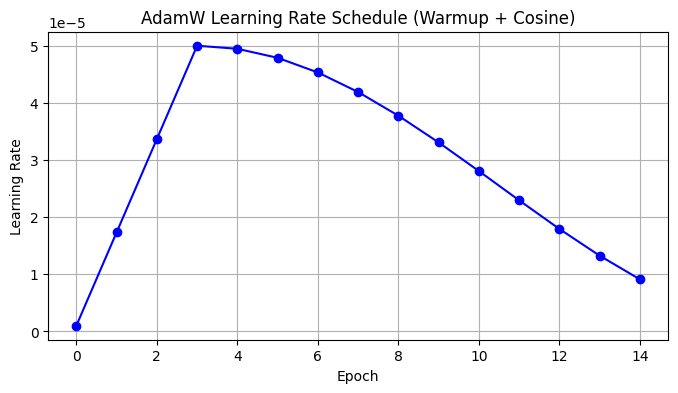

In [16]:
# ==============================================================================
# LEARNING RATE SCHEDULER
# ==============================================================================
from timm.scheduler import CosineLRScheduler

# Setting up the Cosine Scheduler with Warmup
scheduler = CosineLRScheduler(
    optimizer,
    t_initial=Config.EPOCHS,
    lr_min=1e-6,                           # Minimum learning rate at the end of training
    warmup_t=Config.WARMUP_EPOCHS,         # Epochs for warmup phase
    warmup_lr_init=1e-6,                   # Starting extremely low to protect pre-trained weights
    warmup_prefix=True                     # Applies warmup before the main schedule
)

print(f"Scheduler: CosineLRScheduler (Epochs: {Config.EPOCHS}, Warmup: {Config.WARMUP_EPOCHS} epochs)")

# Let's visualize the Learning Rate Schedule to ensure it's correct
def visualize_lr_schedule():
    lrs = []
    # Mock stepping through epochs
    for epoch in range(Config.EPOCHS):
        scheduler.step(epoch)
        lrs.append(optimizer.param_groups[0]['lr'])
    
    plt.figure(figsize=(8, 4))
    plt.plot(range(Config.EPOCHS), lrs, marker='o', color='b')
    plt.title("AdamW Learning Rate Schedule (Warmup + Cosine)")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.grid(True)
    plt.show()
    
    # Reset scheduler to epoch 0 after visualization
    scheduler.step(0)

visualize_lr_schedule()

## Step 3: The Custom Training & Validation Loop
This research-style loop implements:
1. **MixUp/CutMix:** Applied *only* to the training data.
2. **Automatic Mixed Precision (AMP):** Speeds up training on Kaggle GPUs and saves VRAM.
3. **Gradient Clipping:** Prevents exploding gradients, a common issue when fine-tuning Vision Transformers.
4. **Model Checkpointing:** Saves the weights of the model only when it achieves a new high in validation accuracy.

In [19]:
# ==============================================================================
# STEP 3: CUSTOM TRAINING AND VALIDATION LOOP
# ==============================================================================
import time
import copy
from tqdm.auto import tqdm

# We use standard CrossEntropyLoss for validation since MixUp is NOT applied to val data
val_criterion = torch.nn.CrossEntropyLoss()

# To track the best model
best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

# History for plotting
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

# Using the updated non-deprecated GradScaler syntax
scaler = torch.amp.GradScaler('cuda')

print(f"🚀 Starting DeiT-B Training on {device} for {Config.EPOCHS} Epochs...")
start_time = time.time()

for epoch in range(Config.EPOCHS):
    print(f"\n{'-'*30}\nEpoch {epoch+1}/{Config.EPOCHS}\n{'-'*30}")
    
    # --------------------------------------------------------------------------
    # TRAINING PHASE
    # --------------------------------------------------------------------------
    model.train()
    running_train_loss = 0.0
    
    train_pbar = tqdm(train_loader, desc="Training", leave=False)
    for images, targets in train_pbar:
        images, targets = images.to(device), targets.to(device)
        
        # Apply MixUp/CutMix (Dynamically blends images and labels)
        images, targets = mixup_fn(images, targets)
        
        optimizer.zero_grad()
        
        # AMP (Automatic Mixed Precision) Context
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, targets) # SoftTargetCrossEntropy for MixUp
            
        # Backward pass with scaler
        scaler.scale(loss).backward()
        
        # Gradient Clipping (Unscale first, then clip)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        running_train_loss += loss.item() * images.size(0)
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    history['train_loss'].append(epoch_train_loss)
    
    # --------------------------------------------------------------------------
    # VALIDATION PHASE
    # --------------------------------------------------------------------------
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    val_pbar = tqdm(val_loader, desc="Validation", leave=False)
    with torch.no_grad():
        for images, targets in val_pbar:
            images, targets = images.to(device), targets.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = val_criterion(outputs, targets) # Standard CrossEntropy
                
            _, preds = torch.max(outputs, 1)
            
            running_val_loss += loss.item() * images.size(0)
            running_val_corrects += torch.sum(preds == targets.data)
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = running_val_corrects.double() / len(val_dataset)
    
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.item())
    
    print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
    
    # --------------------------------------------------------------------------
    # SCHEDULER STEP & CHECKPOINTING
    # --------------------------------------------------------------------------
    # Step the scheduler at the end of each epoch
    scheduler.step(epoch + 1)
    
    # Deep copy the model if it has the best validation accuracy so far
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        # Save the best model to Kaggle working directory
        torch.save(model.state_dict(), '/kaggle/working/best_deit_model.pth')
        print(f"🌟 New Best Model Saved! (Accuracy: {best_val_acc:.4f})")

time_elapsed = time.time() - start_time
print(f"\n✅ Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")

# Load the best model weights back into the model for final evaluation later
model.load_state_dict(best_model_wts)

🚀 Starting DeiT-B Training on cuda for 15 Epochs...

------------------------------
Epoch 1/15
------------------------------


Training:   0%|          | 0/65 [00:00<?, ?it/s]

Validation:   0%|          | 0/17 [00:00<?, ?it/s]

Train Loss: 1.2175 | Val Loss: 0.3631 | Val Acc: 0.9318
🌟 New Best Model Saved! (Accuracy: 0.9318)

------------------------------
Epoch 2/15
------------------------------


Training:   0%|          | 0/65 [00:00<?, ?it/s]

...

Train Loss: 0.8836 | Val Loss: 0.1473 | Val Acc: 0.9830

------------------------------
Epoch 15/15
------------------------------


Training:   0%|          | 0/65 [00:00<?, ?it/s]

Validation:   0%|          | 0/17 [00:00<?, ?it/s]

Train Loss: 0.8774 | Val Loss: 0.1479 | Val Acc: 0.9830

✅ Training complete in 16m 13s
🏆 Best Validation Accuracy: 0.9886


<All keys matched successfully>

# Visualizing Training Results
#Let's plot the training and validation curves to check for overfitting or underfittingA.

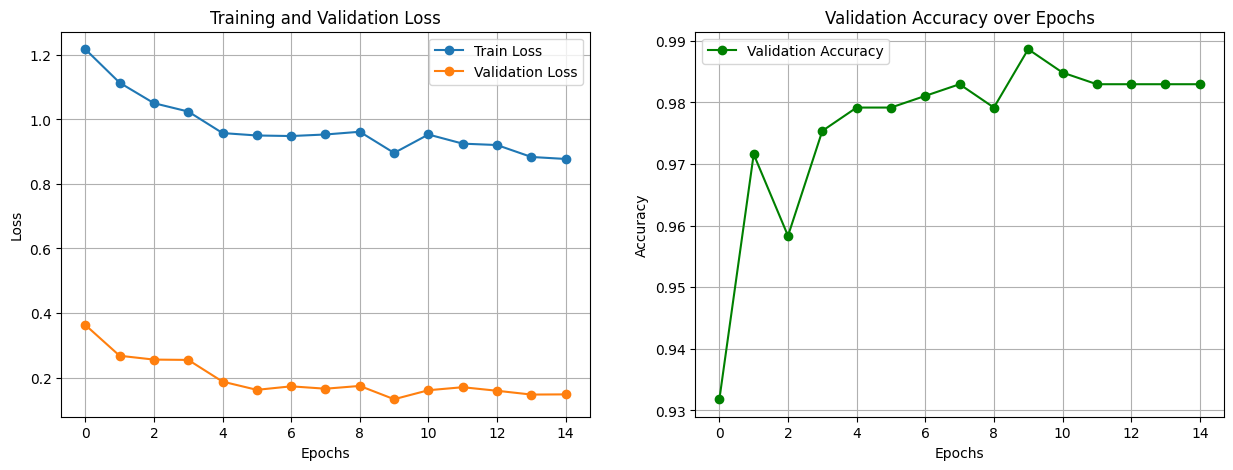

In [20]:
# Plotting the Training and Validation Loss & Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Validation Loss', marker='o')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(history['val_acc'], label='Validation Accuracy', marker='o', color='green')
ax2.set_title('Validation Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()

## Step 4: Model Evaluation (Inference)
First, we run the validation dataset through our best saved model to gather all predictions and true labels. We do this once to save compute time.

In [21]:
# ==============================================================================
# STEP 4.1: GATHER PREDICTIONS FOR EVALUATION
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Ensure model is in eval mode
model.eval()

all_preds = []
all_targets = []
class_labels = val_dataset.classes

print("🔍 Gathering predictions on the validation dataset...")

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        
        # Using AMP for faster inference
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

print("✅ Predictions gathered successfully! Ready for visualization.")

🔍 Gathering predictions on the validation dataset...


Evaluating:   0%|          | 0/17 [00:00<?, ?it/s]

✅ Predictions gathered successfully! Ready for visualization.


###  Standard Kaggle Evaluation (Absolute Counts)
Shows the exact number of correctly and incorrectly classified images.

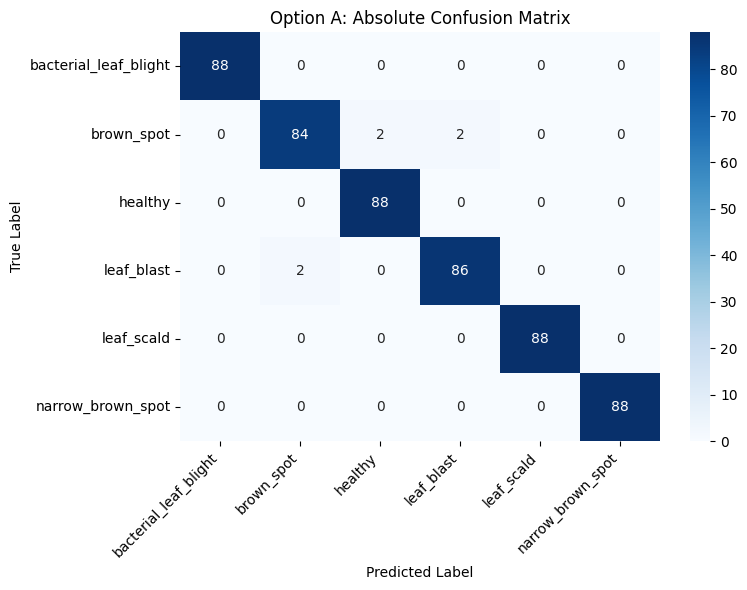


--- Standard Classification Report ---
                       precision    recall  f1-score   support

bacterial_leaf_blight     1.0000    1.0000    1.0000        88
           brown_spot     0.9767    0.9545    0.9655        88
              healthy     0.9778    1.0000    0.9888        88
           leaf_blast     0.9773    0.9773    0.9773        88
           leaf_scald     1.0000    1.0000    1.0000        88
    narrow_brown_spot     1.0000    1.0000    1.0000        88

             accuracy                         0.9886       528
            macro avg     0.9886    0.9886    0.9886       528
         weighted avg     0.9886    0.9886    0.9886       528



In [22]:
# ==============================================================================
# OPTION A: ABSOLUTE CONFUSION MATRIX
# ==============================================================================
cm_absolute = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_absolute, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Option A: Absolute Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- Standard Classification Report ---")
print(classification_report(all_targets, all_preds, target_names=class_labels, digits=4))

###  (Normalized Percentages)
Removes class imbalance bias by showing accuracy percentages per class.

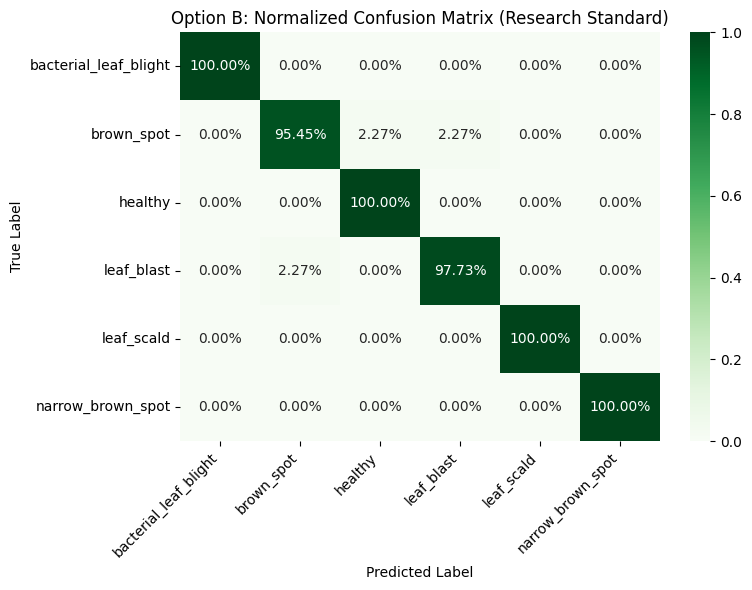

In [23]:
# ==============================================================================
# OPTION B: NORMALIZED CONFUSION MATRIX
# ==============================================================================
cm_normalized = confusion_matrix(all_targets, all_preds, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Option B: Normalized Confusion Matrix (Research Standard)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 5.2: Test Time Augmentation (TTA)
We will create a custom TTA loop. For every image, the model will predict on:
1. The Original Image
2. A Horizontally Flipped version
3. A Vertically Flipped version
We average the softmax probabilities to get the final ultra-robust prediction.

In [37]:
# ==============================================================================
# STEP 5.2: TEST TIME AUGMENTATION (TTA) INFERENCE
# ==============================================================================
import torch.nn.functional as F

print("🚀 Starting TTA Inference...")
model.eval()

tta_preds = []
tta_targets = []

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating with TTA"):
        images = images.to(device)
        
        # 1. Original Prediction
        out_orig = F.softmax(model(images), dim=1)
        
        # 2. Horizontal Flip Prediction
        img_hf = torch.flip(images, dims=[3])
        out_hf = F.softmax(model(img_hf), dim=1)
        
        # 3. Vertical Flip Prediction
        img_vf = torch.flip(images, dims=[2])
        out_vf = F.softmax(model(img_vf), dim=1)
        
        # Average the probabilities
        out_final = (out_orig + out_hf + out_vf) / 3.0
        
        # Get final predictions
        _, preds = torch.max(out_final, 1)
        
        tta_preds.extend(preds.cpu().numpy())
        tta_targets.extend(targets.cpu().numpy())

tta_preds = np.array(tta_preds)
tta_targets = np.array(tta_targets)

# Compare Original Accuracy vs TTA Accuracy
from sklearn.metrics import accuracy_score
tta_acc = accuracy_score(tta_targets, tta_preds)

print(f"\n✅ TTA Evaluation Complete!")
print(f"🎯 Baseline Validation Accuracy: {best_val_acc:.4f}")
print(f"🔥 Final Accuracy with TTA:       {tta_acc:.4f}")

# Let's print the new classification report
print("\n" + "="*50)
print("TTA CLASSIFICATION REPORT")
print("="*50)
print(classification_report(tta_targets, tta_preds, target_names=class_labels, digits=4))

🚀 Starting TTA Inference...


Evaluating with TTA:   0%|          | 0/17 [00:00<?, ?it/s]


✅ TTA Evaluation Complete!
🎯 Baseline Validation Accuracy: 0.9886
🔥 Final Accuracy with TTA:       0.9905

TTA CLASSIFICATION REPORT
                       precision    recall  f1-score   support

bacterial_leaf_blight     1.0000    1.0000    1.0000        88
           brown_spot     0.9882    0.9545    0.9711        88
              healthy     0.9778    1.0000    0.9888        88
           leaf_blast     0.9775    0.9886    0.9831        88
           leaf_scald     1.0000    1.0000    1.0000        88
    narrow_brown_spot     1.0000    1.0000    1.0000        88

             accuracy                         0.9905       528
            macro avg     0.9906    0.9905    0.9905       528
         weighted avg     0.9906    0.9905    0.9905       528



## Production Export (ONNX)
Exporting the highly optimized PyTorch DeiT-B model to ONNX format for seamless cross-platform deployment (FastAPI, ONNXRuntime, Mobile).

In [ ]:

!pip install -q onnx onnxscript

import torch.onnx

# 2. Ensure model is on CPU and in evaluation mode for export
model.eval()
model.to('cpu')

# 3. Create a dummy input tensor that matches the input shape of our model
# Shape: (Batch Size, Channels, Height, Width) -> (1, 3, 224, 224)
dummy_input = torch.randn(1, 3, Config.IMG_SIZE, Config.IMG_SIZE, requires_grad=True)

# 4. Define the export path
onnx_file_path = "/kaggle/working/deit_rice_disease_sota.onnx"

print("⏳ Exporting model to ONNX format...")

# 5. Export the model
torch.onnx.export(
    model,                       # Model being run
    dummy_input,                 # Model input (or a tuple for multiple inputs)
    onnx_file_path,              # Where to save the model
    export_params=True,          # Store the trained parameter weights inside the model file
    opset_version=14,            # ONNX opset version (14 is stable for ViTs)
    do_constant_folding=True,    # Optimize the model by folding constant nodes
    input_names=['input'],       # The model's input names
    output_names=['output'],     # The model's output names
    dynamic_axes={               # Dynamic axes for variable batch sizes during deployment
        'input': {0: 'batch_size'},    
        'output': {0: 'batch_size'}
    }
)

print(f"✅ SOTA Model successfully exported to: {onnx_file_path}")
print("🎉 Project Complete! You can now download the .onnx file from the Kaggle working directory.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 15.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 12.0 MB/s eta 0:00:00
⏳ Exporting model to ONNX format...


/tmp/ipykernel_59/2646090798.py:23: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0806 20:28:58.491000 59 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0806 20:28:59.245000 59 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `VisionTransformer([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VisionTransformer([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).
Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✅ SOTA Model successfully exported to: /kaggle/working/deit_rice_disease_sota.onnx
🎉 Project Complete! You can now download the .onnx file from the Kaggle working directory.


## Error Analysis & Hard Mining
In this section, we extract and visualize the exact images where our model failed. We also look at the **Softmax Confidence Score** to check for model overconfidence.

🔍 Scanning validation set for misclassified images...
⚠️ Total misclassified images found: 6 out of 528


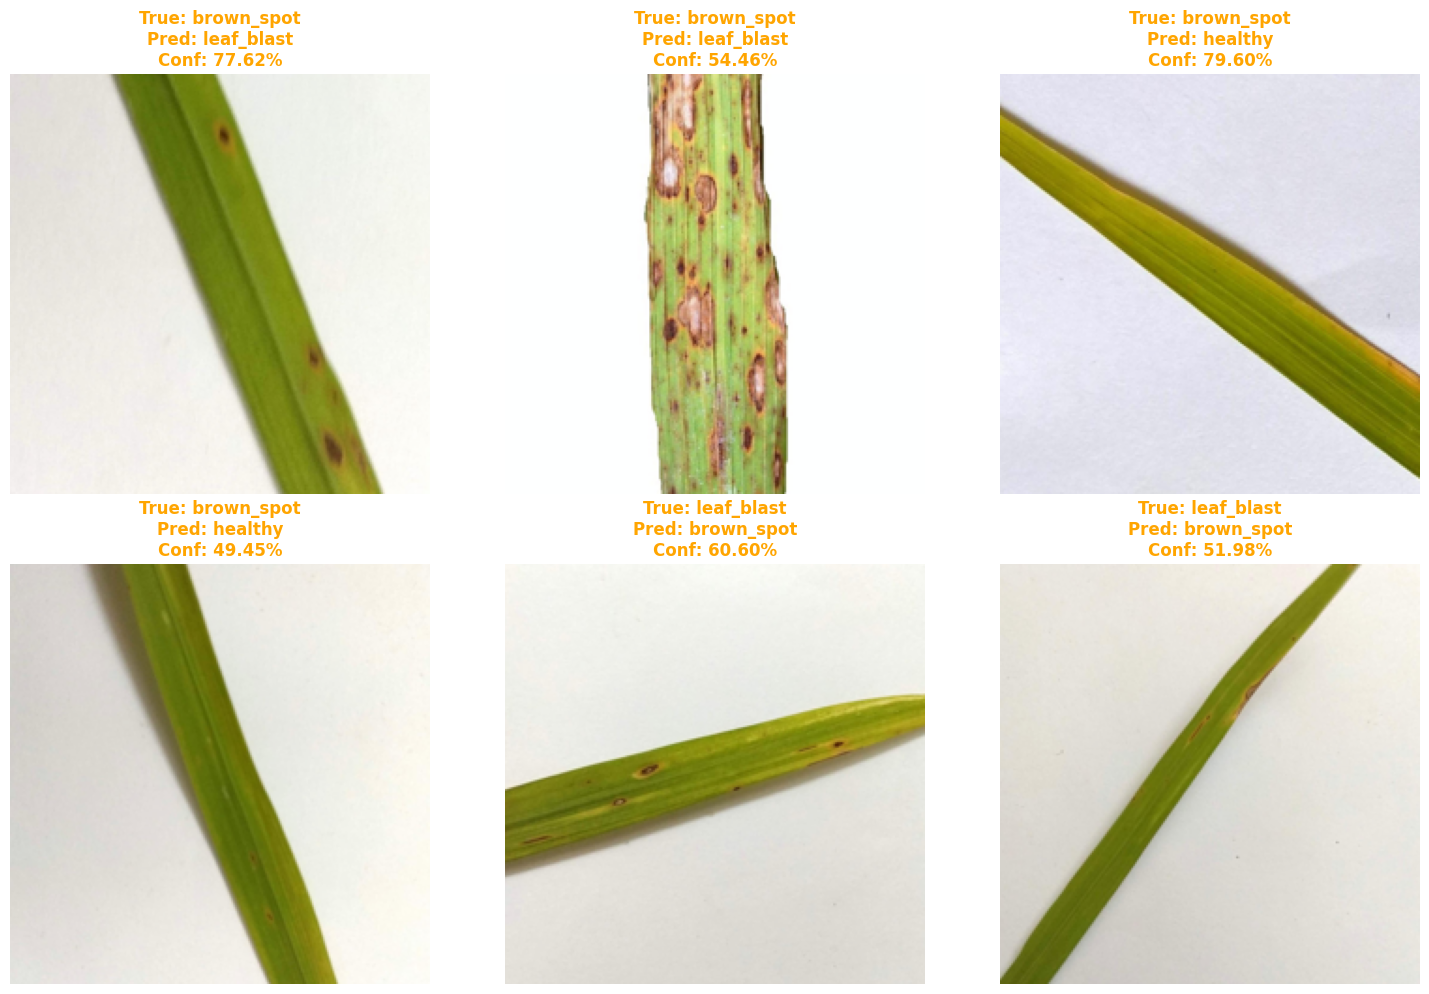

In [ ]:
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print("🔍 Scanning validation set for misclassified images...")

# [THE FIX] Move the model back to the GPU after the ONNX export step
model.to(device) 
model.eval()

misclassified_data = []

with torch.no_grad():
    for images, targets in val_loader:
        images, targets = images.to(device), targets.to(device)
        
        # Get predictions and probabilities
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            
        max_probs, preds = torch.max(probs, 1)
        
        # Find indices where prediction does not match the target
        incorrect_idx = (preds != targets).nonzero(as_tuple=True)[0]
        
        # Store the data for visualization
        for idx in incorrect_idx:
            misclassified_data.append({
                'image': images[idx].cpu(),
                'true_label': targets[idx].item(),
                'pred_label': preds[idx].item(),
                'confidence': max_probs[idx].item()
            })

num_errors = len(misclassified_data)
print(f"⚠️ Total misclassified images found: {num_errors} out of {len(val_dataset)}")

# Visualize the misclassified images if any exist
if num_errors > 0:
    cols = 3
    # Calculate rows needed
    rows = (num_errors + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    
    # Handle single row case where axes is 1D
    if rows == 1:
        axes = np.array([axes])
        
    axes = axes.flatten()
    
    for i in range(len(axes)):
        if i < num_errors:
            data = misclassified_data[i]
            
            # Un-normalize image
            img_np = data['image'].permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_np = std * img_np + mean
            img_np = np.clip(img_np, 0, 1)
            
            true_name = class_labels[data['true_label']]
            pred_name = class_labels[data['pred_label']]
            conf = data['confidence'] * 100
            
            axes[i].imshow(img_np)
            
            # Use Red color if model is highly overconfident (>90%) but wrong
            title_color = 'red' if conf > 90.0 else 'orange'
            
            axes[i].set_title(f"True: {true_name}\nPred: {pred_name}\nConf: {conf:.2f}%", 
                              color=title_color, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].axis('off') # Hide empty subplots
            
    plt.tight_layout()
    plt.show()
else:
    print("🏆 Wow! Zero misclassified images in this standard pass!")

## Production Inference Wrapper & Conclusion
To simulate a real-world backend API, we create a single clean function. You can pass any image path to this function, and it will return the predicted disease and confidence score.

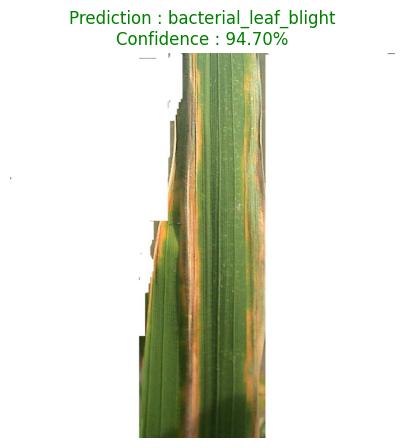

Predicted Class : bacterial_leaf_blight
Confidence      : 94.70%

All Class Probabilities:

bacterial_leaf_blight     : 94.70%
brown_spot                : 0.65%
healthy                   : 1.08%
leaf_blast                : 0.71%
leaf_scald                : 0.78%
narrow_brown_spot         : 2.09%


In [51]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# ==========================
# IMAGE PATH
# ==========================
# Yahan apni image ka custom path daalein
img_path = "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/train/bacterial_leaf_blight/bacterial_leaf_blight (108).jpg" # <-- Change this

try:
    # ==========================
    # Read & Preprocess Image
    # ==========================
    # Image open karna aur humare DeiT ke val_transform se pass karna
    img = Image.open(img_path).convert('RGB')
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    # ==========================
    # Prediction
    # ==========================
    model.eval()
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            output = model(img_tensor)
            # Softmax lagakar 0 to 1 ke beech probabilities nikalna
            probabilities = F.softmax(output, dim=1)[0]
            
    # Get highest confidence and its index
    confidence, pred_idx = torch.max(probabilities, 0)
    pred_class = class_labels[pred_idx.item()]
    conf_val = confidence.item() * 100

    # ==========================
    # Display
    # ==========================
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    # Title color green if confident, orange if slightly confused
    title_color = 'green' if conf_val > 85 else 'orange'
    plt.title(f"Prediction : {pred_class}\nConfidence : {conf_val:.2f}%", color=title_color)
    plt.show()

    # ==========================
    # Console Output
    # ==========================
    print("="*50)
    print(f"Predicted Class : {pred_class}")
    print(f"Confidence      : {conf_val:.2f}%")
    print("="*50)

    print("\nAll Class Probabilities:\n")
    for i, cls in enumerate(class_labels):
        prob = probabilities[i].item() * 100
        print(f"{cls:25s} : {prob:.2f}%")
        
except FileNotFoundError:
    print(f"❌ Error: Image not found at path:\n{img_path}")
    print("Please check the path and try again.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")